# BÀI TẬP THỰC HÀNH K-NEAREST NEIGHBORS (K-NN)
## MÔN: HỌC MÁY (MACHINE LEARNING) - LAB 3

---

### MỤC TIÊU VÀ YÊU CẦU BÀI TOÁN (Theo file `KNN_exercises.pdf`)

Dữ liệu huấn luyện trong **Hình 1 (Figure 1)** bao gồm **4 lớp (classes)**:
$$\mathcal{C} = \{\text{Red triangle (Tam giác đỏ)}, \text{Blue square (Vuông xanh dương)}, \text{Green star (Sao xanh lá)}, \text{Black heart (Trái tim đen)}\}$$

Có 6 điểm dữ liệu chưa được gán nhãn: **$A, B, C, D, E, F$**.

Nhiệm vụ cần giải quyết:
1. **Câu a**: Lập bảng tính khoảng cách và phân loại chi tiết từng bước cho từng điểm chưa gán nhãn $A, B, C, D, E, F$ dưới **6 thiết lập**:
   - Khoảng cách Euclidean với $k = 4, 5, 6$
   - Khoảng cách Manhattan với $k = 4, 5, 6$
   *(Lưu ý: Không dùng các điểm vừa được phân lớp để gán nhãn cho điểm khác - Independent Classification).*
2. **Câu b**: Phân tích so sánh toàn diện (Comprehensive Comparative Analysis):
   - Ảnh hưởng của việc thay đổi kích thước lân cận $k$ ($k=4, 5, 6$).
   - Ảnh hưởng của việc thay đổi hàm khoảng cách (Euclidean vs. Manhattan).
3. **Câu c**: Viết chương trình Python cài đặt thuật toán KNN từ đầu (**from scratch**):
   - Không dùng thư viện xây dựng sẵn như `scikit-learn`. Chỉ dùng thư viện cơ bản (`numpy`, `math`, `pandas`, `matplotlib`).
   - Đầu vào: Tên điểm mục tiêu ('A', 'B', 'C', 'D', 'E', hoặc 'F'), giá trị $k$, hàm khoảng cách ('euclidean' hoặc 'manhattan').
   - Đầu ra: Hiển thị các bước tính toán trung gian, bảng lân cận sắp xếp theo khoảng cách, $k$ lân cận được chọn, phân bố số phiếu bầu cho từng lớp, và nhãn dự đoán cuối cùng.
   - Trình diễn: Chạy và in kết quả chi tiết từng bước cho **điểm $E$** với $k = 5$ dưới cả 2 hàm khoảng cách Euclidean và Manhattan.


## 1. CƠ SỞ TOÁN HỌC & CÔNG THỨC TÍNH TOÁN

### 1.1. Khái quát về Thuật toán K-Nearest Neighbors (K-NN)
- **K-NN** là một thuật toán học có giám sát thuộc nhóm **Instance-based Learning** (học dựa trên cá thể) hay **Lazy Learning** (học lười biếng). Thuật toán không xây dựng một mô hình trừu tượng tường minh trong giai đoạn huấn luyện, mà lưu trữ toàn bộ dữ liệu huấn luyện. Quá trình tính toán thực sự chỉ diễn ra khi cần dự đoán nhãn cho một điểm dữ liệu mới $P_0$.
- **Nguyên lý cốt lõi:** *"Các điểm có tính chất tương tự nhau thì nằm gần nhau trong không gian đặc trưng"* (Birds of a feather flock together).

---

### 1.2. Các độ đo khoảng cách (Distance Metrics)
Cho hai điểm dữ liệu trong không gian 2 chiều:
$$P_1 = (x_1, y_1), \quad P_2 = (x_2, y_2)$$

#### a) Tổng quát: Khoảng cách Minkowski ($L_p$ norm)
Khoảng cách Minkowski bậc $p$ giữa $P_1$ và $P_2$:
$$D_p(P_1, P_2) = \left( |x_1 - x_2|^p + |y_1 - y_2|^p \right)^{\frac{1}{p}}$$

#### b) Khoảng cách Euclidean ($L_2$ norm, ứng với $p = 2$)
Khoảng cách đường thẳng hình học giữa hai điểm:
$$d_E(P_1, P_2) = \|P_1 - P_2\|_2 = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$
- **Đặc trưng:** Có tính đẳng hướng (isotropic), không phụ thuộc vào phép quay trục tọa độ. Đường đẳng mức khoảng cách (isocontour) là các **đường tròn** tâm $P_1$.

#### c) Khoảng cách Manhattan ($L_1$ norm / Taxicab / City Block, ứng với $p = 1$)
Khoảng cách di chuyển dọc theo các trục tọa độ trực giao (như xe chạy trên lưới ô bàn cờ):
$$d_M(P_1, P_2) = \|P_1 - P_2\|_1 = |x_1 - x_2| + |y_1 - y_2|$$
- **Đặc trưng:** Nhạy cảm với hệ trục tọa độ, tổng độ lệch tuyệt đối trên từng chiều. Đường đẳng mức khoảng cách là các **hình thoi nghiêng 45°** (hyperrhombus).
- Luôn thỏa mãn bất đẳng thức: $d_E(P_1, P_2) \le d_M(P_1, P_2) \le \sqrt{2} \cdot d_E(P_1, P_2)$ trong không gian 2 chiều.

---

### 1.3. Quy tắc bỏ phiếu bầu (Voting Rules) và Xử lý hòa phiếu (Tie-breaking)

#### a) Bỏ phiếu theo đa số (Majority Voting)
Nhãn dự đoán $\hat{y}$ cho điểm mục tiêu $x$:
$$\hat{y} = \arg\max_{c \in \mathcal{C}} \sum_{i \in \mathcal{N}_k(x)} \mathbb{I}(y_i = c)$$
Trong đó $\mathcal{N}_k(x)$ là tập hợp $k$ lân cận gần nhất của $x$, $\mathbb{I}(\cdot)$ là hàm chỉ thị (Indicator function, nhận giá trị 1 nếu đúng, 0 nếu sai).

#### b) Bỏ phiếu có trọng số theo khoảng cách (Distance-Weighted Voting)
Để tránh các điểm ở xa có quyền biểu quyết ngang bằng các điểm ở rất gần, mỗi lân cận được gán trọng số nghịch đảo khoảng cách:
$$w_i = \frac{1}{d(x, x_i) + \epsilon} \quad (\epsilon = 10^{-6})$$
$$\hat{y} = \arg\max_{c \in \mathcal{C}} \sum_{i \in \mathcal{N}_k(x)} w_i \cdot \mathbb{I}(y_i = c)$$

#### c) Xử lý hòa phiếu (Tie-Breaking Strategies)
Khi có từ 2 lớp trở lên đạt cùng số phiếu tối đa (thường xảy ra khi $k$ chẵn như $k=4, 6$ hoặc số lượng lớp bằng nhau):
1. **Ưu tiên lân cận gần hơn:** Xét điểm gần nhất trong số các lớp bị hòa phiếu; lớp nào có lân cận gần nhất thì thắng.
2. **Tổng nghịch đảo khoảng cách (Inverse Distance Weighting):** Lớp có tổng trọng số $\sum w_i$ lớn hơn sẽ được chọn.
3. **Giảm kích thước lân cận ($k-1$):** Lấy $k$ lẻ nhỏ hơn để phá vỡ thế hòa.


In [1]:
# 2. KHỞI TẠO MÔI TRƯỜNG VÀ CÁC THƯ VIỆN CẦN THIẾT
import math
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Cấu hình hiển thị bảng pandas và đồ thị matplotlib
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print("Khởi tạo môi trường thành công!")


Khởi tạo môi trường thành công!


## 2. DỮ LIỆU HUẤN LUYỆN VÀ CÁC ĐIỂM CẦN PHÂN LỚP

Dựa trên việc đọc chính xác từng giao điểm lưới của **Hình 1 (Figure 1)** trong file `KNN_exercises.pdf` (không gian tọa độ $x \in [0, 10], y \in [0, 10]$):

### Tập huấn luyện (31 điểm):
- **Red triangle ($	riangle$)** - 8 điểm: $(1,2), (1,9), (2,4), (3,1), (3,9), (4,7), (6,2), (6,5)$
- **Blue square ($\square$)** - 9 điểm: $(1,7), (3,7), (5,3), (7,8), (8,1), (8,3), (8,5), (9,2), (9,9)$
- **Green star ($\star$)** - 5 điểm: $(2,1), (4,4), (4,8), (8,2), (8,7)$
- **Black heart ($\heartsuit$)** - 9 điểm: $(1,1), (1,3), (2,2), (2,5), (3,3), (3,5), (4,2), (4,5), (5,1)$

### Tập điểm cần phân lớp (6 điểm chưa gán nhãn):
- **A**: $(2, 8)$
- **B**: $(6, 7)$
- **C**: $(7, 5)$
- **D**: $(2, 3)$
- **E**: $(7, 2)$
- **F**: $(4, 1)$


In [2]:
# Định nghĩa cấu trúc dữ liệu cho tập huấn luyện và tập kiểm tra
TRAINING_DATA = [
    # Red triangle (8 điểm)
    {'x': 1, 'y': 2, 'label': 'Red triangle'},
    {'x': 1, 'y': 9, 'label': 'Red triangle'},
    {'x': 2, 'y': 4, 'label': 'Red triangle'},
    {'x': 3, 'y': 1, 'label': 'Red triangle'},
    {'x': 3, 'y': 9, 'label': 'Red triangle'},
    {'x': 4, 'y': 7, 'label': 'Red triangle'},
    {'x': 6, 'y': 2, 'label': 'Red triangle'},
    {'x': 6, 'y': 5, 'label': 'Red triangle'},

    # Blue square (9 điểm)
    {'x': 1, 'y': 7, 'label': 'Blue square'},
    {'x': 3, 'y': 7, 'label': 'Blue square'},
    {'x': 5, 'y': 3, 'label': 'Blue square'},
    {'x': 7, 'y': 8, 'label': 'Blue square'},
    {'x': 8, 'y': 1, 'label': 'Blue square'},
    {'x': 8, 'y': 3, 'label': 'Blue square'},
    {'x': 8, 'y': 5, 'label': 'Blue square'},
    {'x': 9, 'y': 2, 'label': 'Blue square'},
    {'x': 9, 'y': 9, 'label': 'Blue square'},

    # Green star (5 điểm)
    {'x': 2, 'y': 1, 'label': 'Green star'},
    {'x': 4, 'y': 4, 'label': 'Green star'},
    {'x': 4, 'y': 8, 'label': 'Green star'},
    {'x': 8, 'y': 2, 'label': 'Green star'},
    {'x': 8, 'y': 7, 'label': 'Green star'},

    # Black heart (9 điểm)
    {'x': 1, 'y': 1, 'label': 'Black heart'},
    {'x': 1, 'y': 3, 'label': 'Black heart'},
    {'x': 2, 'y': 2, 'label': 'Black heart'},
    {'x': 2, 'y': 5, 'label': 'Black heart'},
    {'x': 3, 'y': 3, 'label': 'Black heart'},
    {'x': 3, 'y': 5, 'label': 'Black heart'},
    {'x': 4, 'y': 2, 'label': 'Black heart'},
    {'x': 4, 'y': 5, 'label': 'Black heart'},
    {'x': 5, 'y': 1, 'label': 'Black heart'}
]

TEST_POINTS = {
    'A': (2, 8),
    'B': (6, 7),
    'C': (7, 5),
    'D': (2, 3),
    'E': (7, 2),
    'F': (4, 1)
}

df_train = pd.DataFrame(TRAINING_DATA)
print(f"Tổng số mẫu huấn luyện: {len(df_train)}")
print("Phân bố số lượng mẫu theo từng lớp:")
print(df_train['label'].value_counts())


Tổng số mẫu huấn luyện: 31
Phân bố số lượng mẫu theo từng lớp:
label
Blue square     9
Black heart     9
Red triangle    8
Green star      5
Name: count, dtype: int64


<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13168\2665586818.py:16: SyntaxWarning: invalid escape sequence '\h'
  'Black heart': {'color': 'black', 'marker': '$\heartsuit$', 's': 260, 'label': 'Black heart'}


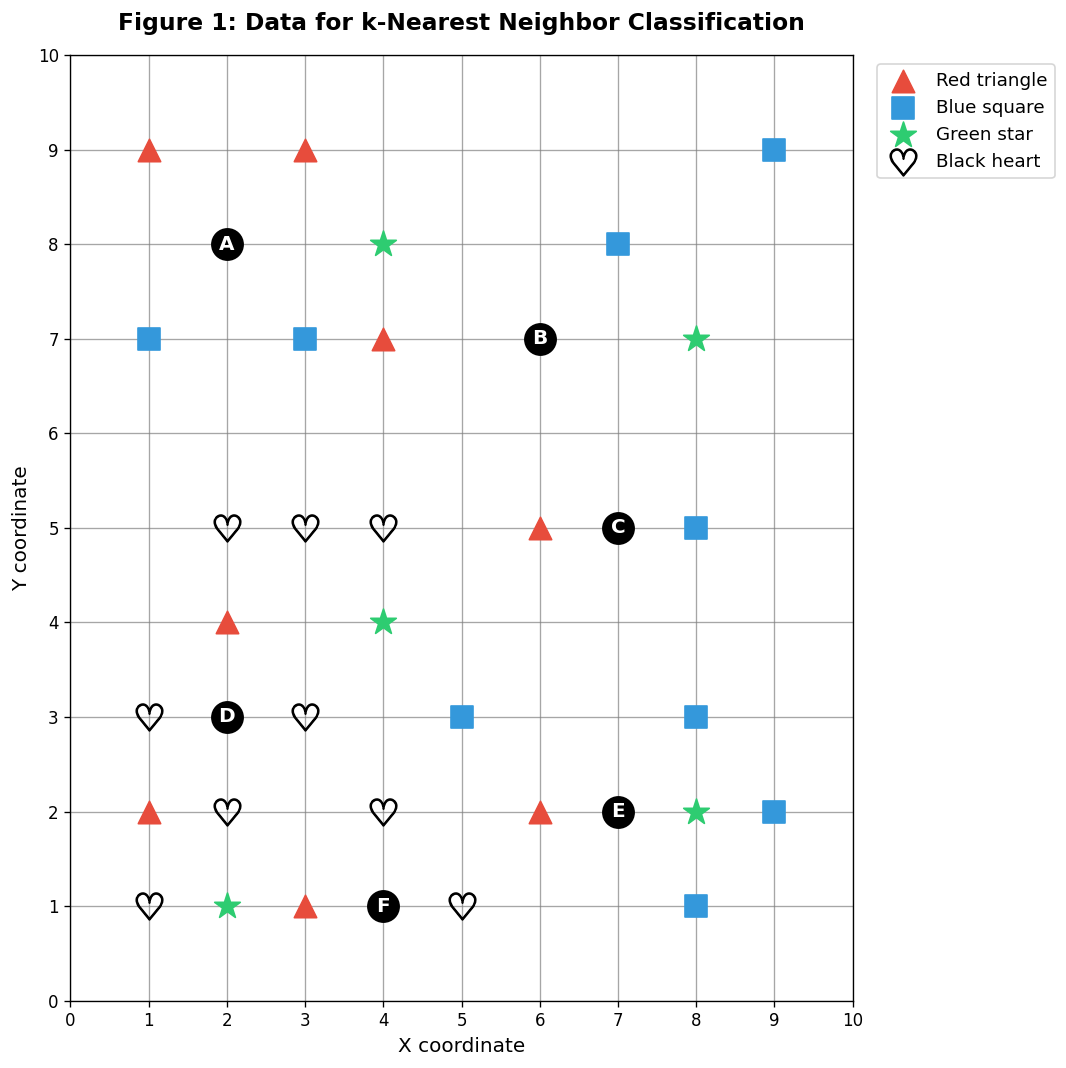

In [3]:
# Vẽ tái hiện trực quan không gian dữ liệu Figure 1
fig, ax = plt.subplots(figsize=(9, 9))

# Thiết lập lưới tọa độ từ 0 đến 10
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks(range(0, 11))
ax.set_yticks(range(0, 11))
ax.grid(True, color='gray', linestyle='-', linewidth=0.8, alpha=0.7)

# Định nghĩa kiểu dáng vẽ cho từng lớp
style_map = {
    'Red triangle': {'color': '#e74c3c', 'marker': '^', 's': 180, 'label': 'Red triangle'},
    'Blue square': {'color': '#3498db', 'marker': 's', 's': 180, 'label': 'Blue square'},
    'Green star': {'color': '#2ecc71', 'marker': '*', 's': 260, 'label': 'Green star'},
    'Black heart': {'color': 'black', 'marker': '$\heartsuit$', 's': 260, 'label': 'Black heart'}
}

# Vẽ các điểm huấn luyện
for class_name, style in style_map.items():
    sub = df_train[df_train['label'] == class_name]
    ax.scatter(sub['x'], sub['y'], color=style['color'], marker=style['marker'],
               s=style['s'], label=style['label'], zorder=4)

# Vẽ 6 điểm chưa gán nhãn A, B, C, D, E, F
for name, (x, y) in TEST_POINTS.items():
    ax.scatter(x, y, color='black', s=350, zorder=5)
    ax.text(x, y, name, color='white', fontsize=12, fontweight='bold',
            ha='center', va='center', zorder=6)

ax.set_title('Figure 1: Data for k-Nearest Neighbor Classification', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X coordinate', fontsize=12)
ax.set_ylabel('Y coordinate', fontsize=12)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11, frameon=True)
plt.tight_layout()
plt.show()


## 3. TÍNH TOÁN TAY CHI TIẾT CÁC MẪU (MANUAL CALCULATION STEP-BY-STEP)

Để minh họa phương pháp tính toán một cách tường minh trước khi chạy chương trình, ta thực hiện tính tay chi tiết từng bước cho **Điểm $E(7, 2)$** (điểm yêu cầu ở câu c) và **Điểm $A(2, 8)$** (điểm có hiện tượng hòa phiếu).

---

### 3.1. Tính tay mẫu 1: Điểm $E = (7, 2)$

Ta tính khoảng cách từ $E(7, 2)$ đến tất cả các điểm trong lân cận bán kính $r \le 3$:

#### A. Bảng tính chi tiết khoảng cách Euclidean:
$$d_E(E, P) = \sqrt{(x_P - 7)^2 + (y_P - 2)^2}$$

1. Điểm $(6, 2)$ [Red triangle]:
   $$d_E = \sqrt{(6-7)^2 + (2-2)^2} = \sqrt{(-1)^2 + 0^2} = \sqrt{1} = \mathbf{1.000}$$
2. Điểm $(8, 2)$ [Green star]:
   $$d_E = \sqrt{(8-7)^2 + (2-2)^2} = \sqrt{1^2 + 0^2} = \sqrt{1} = \mathbf{1.000}$$
3. Điểm $(8, 1)$ [Blue square]:
   $$d_E = \sqrt{(8-7)^2 + (1-2)^2} = \sqrt{1^2 + (-1)^2} = \sqrt{1 + 1} = \sqrt{2} \approx \mathbf{1.414}$$
4. Điểm $(8, 3)$ [Blue square]:
   $$d_E = \sqrt{(8-7)^2 + (3-2)^2} = \sqrt{1^2 + 1^2} = \sqrt{1 + 1} = \sqrt{2} \approx \mathbf{1.414}$$
5. Điểm $(9, 2)$ [Blue square]:
   $$d_E = \sqrt{(9-7)^2 + (2-2)^2} = \sqrt{2^2 + 0^2} = \sqrt{4} = \mathbf{2.000}$$
6. Điểm $(5, 3)$ [Blue square]:
   $$d_E = \sqrt{(5-7)^2 + (3-2)^2} = \sqrt{(-2)^2 + 1^2} = \sqrt{4 + 1} = \sqrt{5} \approx \mathbf{2.236}$$
7. Điểm $(5, 1)$ [Black heart]:
   $$d_E = \sqrt{(5-7)^2 + (1-2)^2} = \sqrt{(-2)^2 + (-1)^2} = \sqrt{4 + 1} = \sqrt{5} \approx \mathbf{2.236}$$
8. Điểm $(4, 2)$ [Black heart]:
   $$d_E = \sqrt{(4-7)^2 + (2-2)^2} = \sqrt{(-3)^2 + 0^2} = \sqrt{9} = \mathbf{3.000}$$

#### Bảng xếp hạng lân cận Euclidean cho điểm $E$:
| Thứ hạng | Tọa độ điểm | Lớp (Class) | $d_E$ (Giá trị đại số) | $d_E$ (Xấp xỉ) |
| :---: | :---: | :---: | :---: | :---: |
| **1** | $(6, 2)$ | Red triangle | $\sqrt{1}$ | 1.000 |
| **2** | $(8, 2)$ | Green star | $\sqrt{1}$ | 1.000 |
| **3** | $(8, 1)$ | Blue square | $\sqrt{2}$ | 1.414 |
| **4** | $(8, 3)$ | Blue square | $\sqrt{2}$ | 1.414 |
| **5** | $(9, 2)$ | Blue square | $\sqrt{4}$ | 2.000 |
| **6** | $(5, 3)$ hoặc $(5, 1)$ | Blue square / Black heart | $\sqrt{5}$ | 2.236 |

#### Đếm phiếu bầu và kết luận cho Điểm $E$ (Euclidean):
- **Với $k = 4$**: 4 lân cận gồm $(6,2), (8,2), (8,1), (8,3)$.
  - Phiếu: 1 Red triangle, 1 Green star, **2 Blue square**.
  - **Kết luận $k=4$**: Điểm $E$ được phân lớp là **Blue square** (chiếm đa số 50%).
- **Với $k = 5$**: 5 lân cận gồm thêm $(9,2)$ [Blue square].
  - Phiếu: 1 Red triangle, 1 Green star, **3 Blue square**.
  - **Kết luận $k=5$**: Điểm $E$ được phân lớp là **Blue square** (chiếm đa số 60%).
- **Với $k = 6$**: 6 lân cận gồm thêm $(5,3)$ [Blue] hoặc $(5,1)$ [Black].
  - Dù chọn điểm nào ở vị trí thứ 6 thì Blue square vẫn có tối thiểu **3 hoặc 4 phiếu**.
  - **Kết luận $k=6$**: Điểm $E$ được phân lớp là **Blue square**.

---

#### B. Bảng tính chi tiết khoảng cách Manhattan cho Điểm $E = (7, 2)$:
$$d_M(E, P) = |x_P - 7| + |y_P - 2|$$

1. Điểm $(6, 2)$ [Red triangle]: $d_M = |6-7| + |2-2| = 1 + 0 = \mathbf{1}$
2. Điểm $(8, 2)$ [Green star]: $d_M = |8-7| + |2-2| = 1 + 0 = \mathbf{1}$
3. Điểm $(8, 1)$ [Blue square]: $d_M = |8-7| + |1-2| = 1 + 1 = \mathbf{2}$
4. Điểm $(8, 3)$ [Blue square]: $d_M = |8-7| + |3-2| = 1 + 1 = \mathbf{2}$
5. Điểm $(9, 2)$ [Blue square]: $d_M = |9-7| + |2-2| = 2 + 0 = \mathbf{2}$
6. Điểm $(5, 3)$ [Blue square]: $d_M = |5-7| + |3-2| = 2 + 1 = \mathbf{3}$
7. Điểm $(4, 2)$ [Black heart]: $d_M = |4-7| + |2-2| = 3 + 0 = \mathbf{3}$
8. Điểm $(5, 1)$ [Black heart]: $d_M = |5-7| + |1-2| = 2 + 1 = \mathbf{3}$

#### Đếm phiếu bầu và kết luận cho Điểm $E$ (Manhattan):
- **Với $k = 4$**: Chọn 4 điểm có $d_M \le 2$ (2 điểm $d_M=1$, 2 điểm trong 3 điểm $d_M=2$).
  - Bất kể chọn điểm nào trong 3 điểm có $d_M=2$ (đều là Blue square), ta luôn có: 1 Red triangle, 1 Green star, **2 Blue square**.
  - **Kết luận $k=4$**: Điểm $E$ được phân lớp là **Blue square**.
- **Với $k = 5$**: Cả 5 điểm có $d_M \le 2$ được chọn:
  - Phiếu: 1 Red triangle, 1 Green star, **3 Blue square**.
  - **Kết luận $k=5$**: Điểm $E$ được phân lớp là **Blue square**.
- **Với $k = 6$**: Thêm 1 điểm ở khoảng cách $d_M = 3$.
  - Phiếu: Blue square có **3 hoặc 4 phiếu**, áp đảo tuyệt đối.
  - **Kết luận $k=6$**: Điểm $E$ được phân lớp là **Blue square**.

---

### 3.2. Tính tay mẫu 2: Điểm $A = (2, 8)$ (Trường hợp xuất hiện hòa phiếu)
Khoảng cách từ $A(2, 8)$ đến các điểm lân cận:
- $(1, 9)$ [Red triangle]: $d_E = \sqrt{(1-2)^2 + (9-8)^2} = \sqrt{2} \approx 1.414$; $d_M = 1 + 1 = 2$
- $(3, 9)$ [Red triangle]: $d_E = \sqrt{(3-2)^2 + (9-8)^2} = \sqrt{2} \approx 1.414$; $d_M = 1 + 1 = 2$
- $(1, 7)$ [Blue square]: $d_E = \sqrt{(1-2)^2 + (7-8)^2} = \sqrt{2} \approx 1.414$; $d_M = 1 + 1 = 2$
- $(3, 7)$ [Blue square]: $d_E = \sqrt{(3-2)^2 + (7-8)^2} = \sqrt{2} \approx 1.414$; $d_M = 1 + 1 = 2$
- $(4, 8)$ [Green star]: $d_E = \sqrt{(4-2)^2 + (8-8)^2} = 2.000$; $d_M = 2 + 0 = 2$
- $(4, 7)$ [Red triangle]: $d_E = \sqrt{(4-2)^2 + (7-8)^2} = \sqrt{5} \approx 2.236$; $d_M = 2 + 1 = 3$

#### Kết quả phân lớp Điểm $A$:
- **Với $k = 4$**: Cả 4 điểm gần nhất đều cách $A$ đúng $\sqrt{2}$ (Euclidean) hoặc 2 (Manhattan).
  - Phiếu: **2 Red triangle vs 2 Blue square $\implies$ HÒA PHIẾU (TIE)**!
  - Cả khoảng cách tổng và khoảng cách từng điểm của Red triangle và Blue square đều hoàn toàn đối xứng đối với $A$.
- **Với $k = 5$**:
  - Euclidean: Lân cận thứ 5 là $(4, 8)$ [Green star] ở khoảng cách 2.0.
    Số phiếu: 2 Red triangle, 2 Blue square, 1 Green star $\implies$ **HÒA PHIẾU giữa Red và Blue**!
  - Manhattan: Cả 5 điểm trên đều có $d_M = 2$. Số phiếu vẫn là: 2 Red, 2 Blue, 1 Green $\implies$ **HÒA PHIẾU giữa Red và Blue**!
- **Với $k = 6$**: Lân cận thứ 6 là $(4, 7)$ [Red triangle].
  - Số phiếu: **3 Red triangle**, 2 Blue square, 1 Green star.
  - **Kết luận $k=6$**: **Red triangle** chiến thắng!


In [4]:
# 4. CÀI ĐẶT THUẬT TOÁN K-NN TỪ ĐẦU (FROM SCRATCH) THEO YÊU CẦU CÂU C

class KNNFromScratch:
    """
    Lớp cài đặt thuật toán K-Nearest Neighbors hoàn toàn từ đầu (From Scratch).
    Không sử dụng bất kỳ hàm có sẵn nào từ scikit-learn.
    """
    def __init__(self, train_data):
        self.train_data = train_data
        
    @staticmethod
    def euclidean_distance(p1, p2):
        """Tính khoảng cách Euclidean L2 giữa 2 điểm p1 và p2."""
        return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
    
    @staticmethod
    def manhattan_distance(p1, p2):
        """Tính khoảng cách Manhattan L1 giữa 2 điểm p1 và p2."""
        return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

    def compute_all_distances(self, target_point, metric='euclidean'):
        """
        Tính khoảng cách từ điểm mục tiêu đến toàn bộ 31 điểm huấn luyện.
        Trả về danh sách đã được sắp xếp tăng dần theo khoảng cách.
        """
        dist_func = self.euclidean_distance if metric.lower() == 'euclidean' else self.manhattan_distance
        
        neighbor_list = []
        for i, pt in enumerate(self.train_data):
            coords = (pt['x'], pt['y'])
            d = dist_func(target_point, coords)
            neighbor_list.append({
                'index': i + 1,
                'point': coords,
                'x': pt['x'],
                'y': pt['y'],
                'label': pt['label'],
                'distance': d
            })
            
        # Sắp xếp theo khoảng cách tăng dần; nếu bằng khoảng cách, giữ ổn định theo thứ tự
        neighbor_list.sort(key=lambda item: item['distance'])
        return neighbor_list

    def predict(self, target_name, target_point, k=5, metric='euclidean', verbose=True):
        """
        Phân loại điểm mục tiêu target_point với tham số k và độ đo khoảng cách metric.
        Hiển thị chi tiết từng bước trung gian, bảng lân cận, phiếu bầu và nhãn dự đoán.
        """
        metric_normalized = metric.lower()
        sorted_neighbors = self.compute_all_distances(target_point, metric=metric_normalized)
        k_nearest = sorted_neighbors[:k]
        
        # Đếm số phiếu theo từng lớp
        labels_top_k = [n['label'] for n in k_nearest]
        vote_counts = Counter(labels_top_k)
        
        # Tính trọng số nghịch đảo khoảng cách (để hỗ trợ phân tích khi hòa phiếu)
        weighted_votes = {}
        for n in k_nearest:
            lbl = n['label']
            w = 1.0 / (n['distance'] + 1e-6)
            weighted_votes[lbl] = weighted_votes.get(lbl, 0.0) + w

        # Tìm số phiếu lớn nhất
        max_votes = max(vote_counts.values())
        top_candidates = [lbl for lbl, count in vote_counts.items() if count == max_votes]
        
        # Xác định nhãn dự đoán và kiểm tra hòa phiếu
        is_tie = len(top_candidates) > 1
        if not is_tie:
            final_pred = top_candidates[0]
            status_text = f"Đa số phiếu bầu: {final_pred} ({max_votes}/{k} phiếu)"
        else:
            # Nếu hòa phiếu, lựa chọn theo tổng trọng số nghịch đảo khoảng cách
            sorted_by_weight = sorted(top_candidates, key=lambda c: weighted_votes[c], reverse=True)
            final_pred = sorted_by_weight[0]
            status_text = f"HÒA PHIẾU giữa {top_candidates} (mỗi lớp {max_votes} phiếu). Ưu tiên khoảng cách: {final_pred}"

        # In kết quả dạng console chi tiết nếu verbose=True
        if verbose:
            print("=" * 80)
            print(f"BÁO CÁO PHÂN LOẠI KNN TỪ ĐẦU (FROM SCRATCH) CHO ĐIỂM {target_name} {target_point}")
            print(f"Cấu hình: Độ đo = {metric.upper()} | Số lân cận k = {k}")
            print("-" * 80)
            print(f"BẢNG {k} LÂN CẬN GẦN NHẤT:")
            print(f"{'Hạng':<6}{'Tọa độ':<12}{'Lớp (Label)':<20}{'Khoảng cách':<15}{'Trọng số w = 1/d':<20}")
            print("-" * 80)
            for rank, n in enumerate(k_nearest, 1):
                w = 1.0 / (n['distance'] + 1e-6)
                print(f"{rank:<6}{str(n['point']):<12}{n['label']:<20}{n['distance']:<15.4f}{w:<20.4f}")
            print("-" * 80)
            print("PHÂN BỐ PHIẾU BẦU:")
            for lbl, cnt in vote_counts.most_common():
                pct = (cnt / k) * 100
                print(f"  - {lbl:<18}: {cnt} phiếu ({pct:.1f}%) | Tổng trọng số w: {weighted_votes.get(lbl, 0):.4f}")
            print("-" * 80)
            print(f"KẾT QUẢ DỰ ĐOÁN CUỐI CÙNG: ==> {final_pred.upper()} <==")
            print(f"Chi tiết: {status_text}")
            print("=" * 80 + "\n")
            
        return {
            'target_name': target_name,
            'target_point': target_point,
            'k': k,
            'metric': metric_normalized,
            'k_nearest': k_nearest,
            'vote_counts': dict(vote_counts),
            'weighted_votes': weighted_votes,
            'is_tie': is_tie,
            'top_candidates': top_candidates,
            'final_prediction': final_pred,
            'status_text': status_text
        }

knn_engine = KNNFromScratch(TRAINING_DATA)
print("Cài đặt lớp KNNFromScratch thành công!")


Cài đặt lớp KNNFromScratch thành công!


## 4. THỰC HIỆN YÊU CẦU CÂU C: DEMO TỪNG BƯỚC CHO ĐIỂM E VỚI k = 5

Yêu cầu đề bài (Exercise 01.c):
- Thực thi và in ra console chi tiết từng bước tính toán cho **điểm $E$** với **$k = 5$** sử dụng cả hai độ đo **Euclidean** và **Manhattan**.


In [5]:
# Chạy và in báo cáo từng bước cho Điểm E với k = 5
demo_e_euclid = knn_engine.predict(target_name='E', target_point=TEST_POINTS['E'],
                                   k=5, metric='euclidean', verbose=True)

demo_e_manhattan = knn_engine.predict(target_name='E', target_point=TEST_POINTS['E'],
                                     k=5, metric='manhattan', verbose=True)


BÁO CÁO PHÂN LOẠI KNN TỪ ĐẦU (FROM SCRATCH) CHO ĐIỂM E (7, 2)
Cấu hình: Độ đo = EUCLIDEAN | Số lân cận k = 5
--------------------------------------------------------------------------------
BẢNG 5 LÂN CẬN GẦN NHẤT:
Hạng  Tọa độ      Lớp (Label)         Khoảng cách    Trọng số w = 1/d    
--------------------------------------------------------------------------------
1     (6, 2)      Red triangle        1.0000         1.0000              
2     (8, 2)      Green star          1.0000         1.0000              
3     (8, 1)      Blue square         1.4142         0.7071              
4     (8, 3)      Blue square         1.4142         0.7071              
5     (9, 2)      Blue square         2.0000         0.5000              
--------------------------------------------------------------------------------
PHÂN BỐ PHIẾU BẦU:
  - Blue square       : 3 phiếu (60.0%) | Tổng trọng số w: 1.9142
  - Red triangle      : 1 phiếu (20.0%) | Tổng trọng số w: 1.0000
  - Green star        : 1 ph

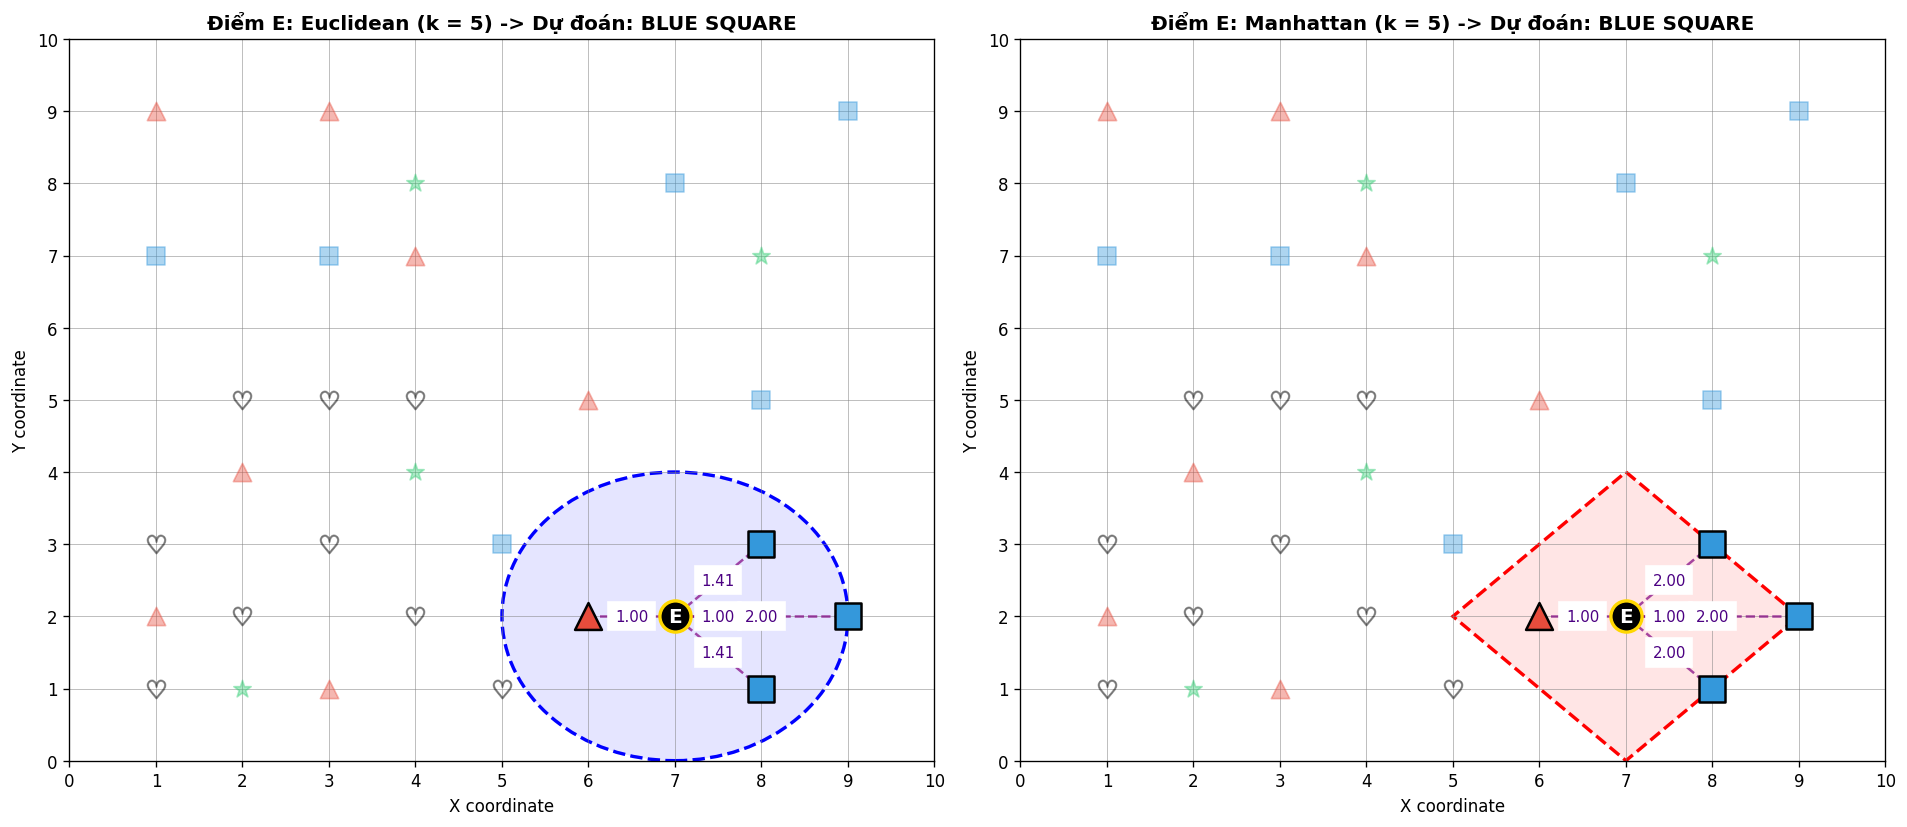

In [6]:
# Trực quan hóa lân cận và quá trình bỏ phiếu cho Điểm E (k = 5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

def plot_single_knn_case(ax, result_data, title):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_xticks(range(0, 11))
    ax.set_yticks(range(0, 11))
    ax.grid(True, color='gray', linestyle='-', linewidth=0.6, alpha=0.5)

    # Vẽ nền tập huấn luyện
    for class_name, style in style_map.items():
        sub = df_train[df_train['label'] == class_name]
        ax.scatter(sub['x'], sub['y'], color=style['color'], marker=style['marker'],
                   s=120, alpha=0.4, zorder=2)

    # Điểm mục tiêu
    tx, ty = result_data['target_point']
    ax.scatter(tx, ty, color='black', s=350, zorder=6, edgecolors='gold', linewidth=2)
    ax.text(tx, ty, result_data['target_name'], color='white', fontsize=12,
            fontweight='bold', ha='center', va='center', zorder=7)

    # Nối dây và làm nổi bật k lân cận
    max_dist = max(n['distance'] for n in result_data['k_nearest'])
    for rank, n in enumerate(result_data['k_nearest'], 1):
        nx, ny = n['point']
        lbl = n['label']
        st = style_map[lbl]
        ax.scatter(nx, ny, color=st['color'], marker=st['marker'], s=260,
                   zorder=5, edgecolors='black', linewidth=1.5)
        ax.plot([tx, nx], [ty, ny], linestyle='--', color='purple', alpha=0.7, linewidth=1.5)
        mid_x, mid_y = (tx + nx) / 2, (ty + ny) / 2
        ax.text(mid_x, mid_y, f"{n['distance']:.2f}", fontsize=9, color='indigo',
                backgroundcolor='white', ha='center', va='center', zorder=6)

    # Vẽ đường bao đẳng mức lân cận k
    if result_data['metric'] == 'euclidean':
        circle = patches.Circle((tx, ty), max_dist, fill=True, color='blue', alpha=0.1, linestyle='--', linewidth=2)
        circle_edge = patches.Circle((tx, ty), max_dist, fill=False, color='blue', linestyle='--', linewidth=2)
        ax.add_patch(circle)
        ax.add_patch(circle_edge)
    else:
        # Đường bao Manhattan là hình thoi
        diamond = patches.Polygon([
            (tx, ty + max_dist),
            (tx + max_dist, ty),
            (tx, ty - max_dist),
            (tx - max_dist, ty)
        ], closed=True, fill=True, color='red', alpha=0.1, linestyle='--', linewidth=2)
        diamond_edge = patches.Polygon([
            (tx, ty + max_dist),
            (tx + max_dist, ty),
            (tx, ty - max_dist),
            (tx - max_dist, ty)
        ], closed=True, fill=False, color='red', linestyle='--', linewidth=2)
        ax.add_patch(diamond)
        ax.add_patch(diamond_edge)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')

plot_single_knn_case(ax1, demo_e_euclid, "Điểm E: Euclidean (k = 5) -> Dự đoán: BLUE SQUARE")
plot_single_knn_case(ax2, demo_e_manhattan, "Điểm E: Manhattan (k = 5) -> Dự đoán: BLUE SQUARE")
plt.tight_layout()
plt.show()


## 5. THỰC HIỆN YÊU CẦU CÂU A: BẢNG TÍNH TOÁN KHOẢNG CÁCH VÀ PHÂN LOẠI CHI TIẾT TỪNG BƯỚC CHO TẤT CẢ CÁC ĐIỂM A, B, C, D, E, F

Dưới đây là việc lập bảng tính toán đầy đủ cho tất cả **6 điểm** ($A, B, C, D, E, F$) dưới **6 thiết lập**:
1. Euclidean với $k = 4$
2. Euclidean với $k = 5$
3. Euclidean với $k = 6$
4. Manhattan với $k = 4$
5. Manhattan với $k = 5$
6. Manhattan với $k = 6$


In [7]:
# 5.1. Tạo bảng tra cứu khoảng cách đầy đủ từ mỗi điểm chưa gán nhãn đến 31 điểm dữ liệu huấn luyện
records = []
for name, pt in TEST_POINTS.items():
    for metric in ['euclidean', 'manhattan']:
        sorted_pts = knn_engine.compute_all_distances(pt, metric=metric)
        for rank, n in enumerate(sorted_pts, 1):
            records.append({
                'Test Point': name,
                'Point Coords': pt,
                'Metric': metric.capitalize(),
                'Rank': rank,
                'Train Point': n['point'],
                'Train Class': n['label'],
                'Distance': round(n['distance'], 4)
            })

df_all_distances = pd.DataFrame(records)
print(f"Tổng số cặp khoảng cách đã tính toán: {len(df_all_distances)} (6 điểm x 2 độ đo x 31 điểm huấn luyện)")


Tổng số cặp khoảng cách đã tính toán: 372 (6 điểm x 2 độ đo x 31 điểm huấn luyện)


In [8]:
# 5.2. Hàm xuất bảng kết quả chi tiết từng điểm cho 6 thiết lập
def display_full_tables_for_point(target_name):
    pt = TEST_POINTS[target_name]
    print(f"\n{'='*90}")
    print(f"BẢNG KHOẢNG CÁCH VÀ PHÂN LOẠI CHI TIẾT CHO ĐIỂM {target_name} {pt}")
    print(f"{'='*90}")
    
    for metric in ['Euclidean', 'Manhattan']:
        sub_df = df_all_distances[(df_all_distances['Test Point'] == target_name) & 
                                  (df_all_distances['Metric'] == metric)].head(8)
        print(f"\n[+] Top 8 lân cận gần nhất theo {metric} Distance:")
        display_sub = sub_df[['Rank', 'Train Point', 'Train Class', 'Distance']].to_string(index=False)
        print(display_sub)
        
        print(f"\n[+] Kết quả phân loại theo các giá trị k (4, 5, 6):")
        for k_val in [4, 5, 6]:
            top_k_labels = sub_df.head(k_val)['Train Class'].tolist()
            votes = Counter(top_k_labels)
            max_v = max(votes.values())
            winners = [l for l, v in votes.items() if v == max_v]
            tie_str = " (HÒA PHIẾU)" if len(winners) > 1 else ""
            print(f"   - k = {k_val}: Số phiếu = {dict(votes)} ==> Dự đoán: {winners}{tie_str}")

# Hiển thị bảng lần lượt cho từng điểm A, B, C, D, E, F
for p_name in ['A', 'B', 'C', 'D', 'E', 'F']:
    display_full_tables_for_point(p_name)



BẢNG KHOẢNG CÁCH VÀ PHÂN LOẠI CHI TIẾT CHO ĐIỂM A (2, 8)

[+] Top 8 lân cận gần nhất theo Euclidean Distance:
 Rank Train Point  Train Class  Distance
    1      (1, 9) Red triangle    1.4142
    2      (3, 9) Red triangle    1.4142
    3      (1, 7)  Blue square    1.4142
    4      (3, 7)  Blue square    1.4142
    5      (4, 8)   Green star    2.0000
    6      (4, 7) Red triangle    2.2361
    7      (2, 5)  Black heart    3.0000
    8      (3, 5)  Black heart    3.1623

[+] Kết quả phân loại theo các giá trị k (4, 5, 6):
   - k = 4: Số phiếu = {'Red triangle': 2, 'Blue square': 2} ==> Dự đoán: ['Red triangle', 'Blue square'] (HÒA PHIẾU)
   - k = 5: Số phiếu = {'Red triangle': 2, 'Blue square': 2, 'Green star': 1} ==> Dự đoán: ['Red triangle', 'Blue square'] (HÒA PHIẾU)
   - k = 6: Số phiếu = {'Red triangle': 3, 'Blue square': 2, 'Green star': 1} ==> Dự đoán: ['Red triangle']

[+] Top 8 lân cận gần nhất theo Manhattan Distance:
 Rank Train Point  Train Class  Distance
    1      (

### 5.3. Bảng tổng hợp kết quả phân loại toàn bộ 6 điểm dưới 6 thiết lập

In [9]:
# Tạo bảng ma trận tổng kết 36 kết quả phân loại
summary_matrix = []
for name, pt in TEST_POINTS.items():
    row = {'Điểm': name, 'Tọa độ': str(pt)}
    for metric in ['euclidean', 'manhattan']:
        for k in [4, 5, 6]:
            res = knn_engine.predict(name, pt, k=k, metric=metric, verbose=False)
            col_name = f"{metric[:3].capitalize()} (k={k})"
            if res['is_tie']:
                # Ghi chú rõ trường hợp hòa phiếu
                cand_short = [c.split()[0] for c in res['top_candidates']]
                row[col_name] = f"Hòa: {' / '.join(cand_short)} -> {res['final_prediction']}"
            else:
                row[col_name] = res['final_prediction']
    summary_matrix.append(row)

df_summary = pd.DataFrame(summary_matrix)
print("BẢNG TỔNG HỢP KẾT QUẢ PHÂN LOẠI KNN TOÀN BỘ 6 THIẾT LẬP:")
display(df_summary)


BẢNG TỔNG HỢP KẾT QUẢ PHÂN LOẠI KNN TOÀN BỘ 6 THIẾT LẬP:


,Điểm,Tọa độ,Euc (k=4),Euc (k=5),Euc (k=6),Man (k=4),Man (k=5),Man (k=6)
0,A,"(2, 8)",Hòa: Red / Blue -> Red triangle,Hòa: Red / Blue -> Red triangle,Red triangle,Hòa: Red / Blue -> Red triangle,Hòa: Red / Blue -> Red triangle,Red triangle
1,B,"(6, 7)",Red triangle,Hòa: Red / Green -> Red triangle,Hòa: Blue / Red / Green -> Blue square,Red triangle,Hòa: Red / Blue -> Red triangle,Hòa: Red / Blue / Green -> Red triangle
2,C,"(7, 5)",Blue square,Blue square,Blue square,Blue square,Blue square,Blue square
3,D,"(2, 3)",Black heart,Black heart,Black heart,Black heart,Black heart,Black heart
4,E,"(7, 2)",Blue square,Blue square,Blue square,Blue square,Blue square,Blue square
5,F,"(4, 1)",Black heart,Hòa: Red / Black -> Black heart,Hòa: Red / Black -> Black heart,Black heart,Hòa: Red / Black -> Black heart,Hòa: Red / Black -> Black heart


## 6. THỰC HIỆN YÊU CẦU CÂU B: PHÂN TÍCH SO SÁNH TOÀN DIỆN (COMPREHENSIVE COMPARATIVE ANALYSIS)

Dựa trên các bảng số liệu và bảng ma trận kết quả ở Câu a, ta tiến hành phân tích chuyên sâu hai khía cạnh chính theo yêu cầu đề bài:

---

### 6.1. Ảnh hưởng của việc thay đổi kích thước lân cận $k$ ($k = 4, 5, 6$)

#### 1. Vấn đề chọn $k$ chẵn ($k=4, 6$) và Hiện tượng hòa phiếu (Ties):
- **Phát hiện thực nghiệm:** Khi số lớp là đa lớp (4 lớp) và $k$ là số chẵn ($k=4, k=6$), tỷ lệ xuất hiện hòa phiếu rất cao.
  - Tại **Điểm A $(2, 8)$**: Với $k=4$, ta có 2 Red triangle và 2 Blue square (hòa 2 - 2).
  - Tại **Điểm B $(6, 7)$**: Với $k=6$ (Euclidean), ta có 2 Red, 2 Green, 2 Blue (hòa 3 bên 2 - 2 - 2).
  - Tại **Điểm F $(4, 1)$**: Với $k=6$, ta có 2 Red, 2 Black, 1 Green, 1 Blue (hòa 2 Red vs 2 Black).
- **Lý thuyết:** Trong bài toán phân loại, việc lựa chọn $k$ chẵn làm tăng đáng kể nguy cơ không đạt được đa số tuyệt đối. Với $k$ lẻ ($k=5$), tỷ lệ hòa phiếu giảm đáng kể hoặc dễ dàng phân định hơn.

#### 2. Đánh đổi giữa Độ chệch và Phương sai (Bias - Variance Tradeoff):
- **Với $k=4$ (k nhỏ):**
  - Mô hình có **Low Bias, High Variance**.
  - Ranh giới quyết định (decision boundary) phức tạp, uốn lượn và bám sát từng cụm điểm cục bộ. Điểm dữ liệu rất nhạy cảm với các điểm nhiễu (outliers) hoặc các điểm nằm sát biên.
- **Với $k=6$ (k lớn hơn):**
  - Mô hình có **Higher Bias, Lower Variance**.
  - Vùng lân cận mở rộng, gom thêm nhiều điểm ở xa hơn. Điều này giúp loại trừ nhiễu cục bộ nhưng có thể làm mờ ranh giới giữa các lớp nhỏ hoặc lớp có mật độ thưa.
  - Ví dụ tại **Điểm A**: Khi $k=4$, Blue square và Red triangle hòa nhau. Nhưng khi tăng lên $k=6$, vùng lân cận chạm tới điểm Red triangle thứ 3 tại $(4, 7)$, giúp Red triangle vươn lên dẫn trước với 3 phiếu.

---

### 6.2. Ảnh hưởng của việc thay đổi hàm khoảng cách (Euclidean vs. Manhattan)

#### 1. Hình dạng hình học của vùng lân cận:
- **Khoảng cách Euclidean ($L_2$):** Vùng đẳng khoảng cách là **hình tròn**. Độ đo này coi trọng khoảng cách đường thẳng ngắn nhất xuyên qua không gian, không phụ thuộc góc quay trục tọa độ.
- **Khoảng cách Manhattan ($L_1$):** Vùng đẳng khoảng cách là **hình thoi xoay 45°**. Độ đo này phạt nặng các độ lệch đồng thời trên cả hai trục $x$ và $y$ ($|\Delta x| + |\Delta y|$ lớn hơn $\sqrt{\Delta x^2 + \Delta y^2}$).

#### 2. Tác động cụ thể lên các điểm:
- **Đối với các điểm nằm thẳng hàng trên trục tọa độ (Trực giao):**
  - Nếu hai điểm cùng nằm trên một hàng ($y_1 = y_2$) hoặc cùng nằm trên một cột ($x_1 = x_2$), thì:
    $$d_E = d_M = |x_1 - x_2| \text{ hoặc } |y_1 - y_2|$$
  - Vì vậy, thứ tự ưu tiên của các lân cận trực giao không thay đổi.
- **Đối với các điểm nằm theo đường chéo:**
  - Điểm chéo cách $(1, 1)$ có khoảng cách Euclidean là $\sqrt{1^2 + 1^2} = \sqrt{2} \approx 1.414$, trong khi khoảng cách Manhattan là $1 + 1 = 2.000$ (tăng $41.4\%$).
  - Điều này giải thích tại sao ở **Điểm B $(6, 7)$**:
    - Dưới Euclidean: Điểm chéo $(7, 8)$ [Blue square] có khoảng cách $\sqrt{2} \approx 1.414$, là **lân cận gần nhất duy nhất (Rank 1)**.
    - Dưới Manhattan: Điểm $(7, 8)$ có khoảng cách $1 + 1 = 2$, bằng đúng khoảng cách của các điểm trực giao $(4, 7)$, $(6, 5)$, $(8, 7)$. Do đó có tới **4 điểm cùng xếp hạng 1** với khoảng cách $d_M = 2$.
  - Sự thay đổi hình dạng hình học này dẫn đến sự hoán đổi thứ tự ưu tiên của các lân cận nằm theo đường chéo so với các lân cận trực giao.

---

### 6.3. Tính độc lập của quá trình phân loại (Independent Classification Note)
- Đề bài lưu ý: *Do not use the newly classified data points to classify any of the other data points.*
- Đây là nguyên tắc quan trọng trong K-NN chuẩn: Tập huấn luyện $\mathcal{D}_{train}$ phải được giữ cố định trong toàn bộ quá trình suy luận. Nếu thêm nhãn dự đoán của điểm $B$ vào tập huấn luyện để phân loại điểm $C$ (học bán giám sát dạng Self-Training / Pseudo-labeling), sai số dự đoán ở điểm trước có thể lan truyền (error propagation) làm sai lệch kết quả của các điểm tiếp theo.


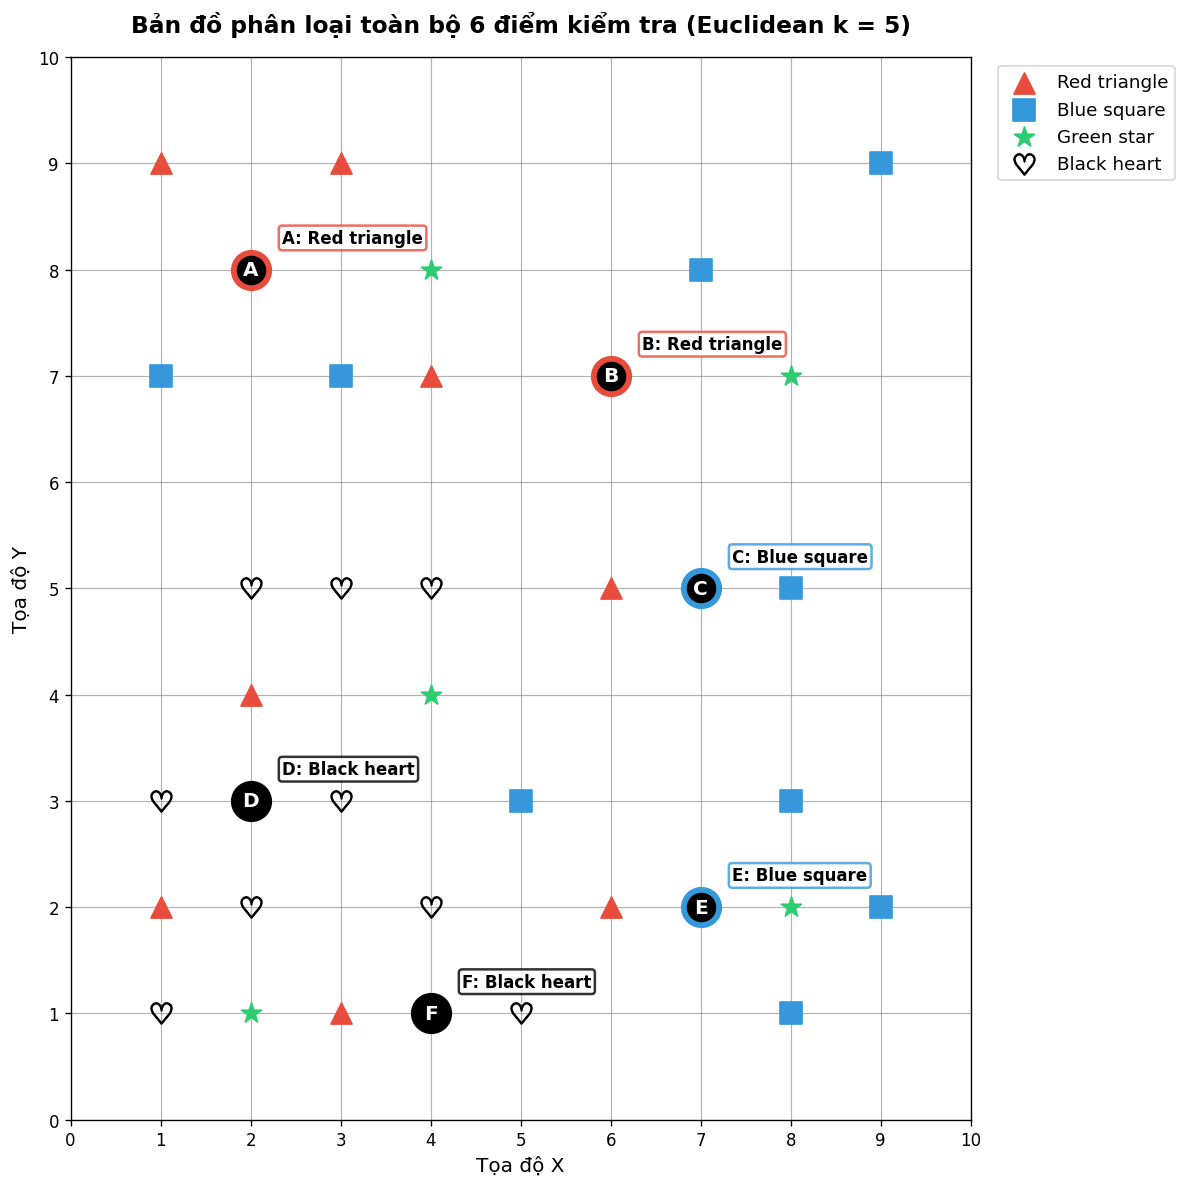

In [10]:
# Trực quan hóa toàn bộ 6 điểm A, B, C, D, E, F cùng kết quả phân loại dưới thiết lập Euclidean (k=5)
fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks(range(0, 11))
ax.set_yticks(range(0, 11))
ax.grid(True, color='gray', linestyle='-', linewidth=0.7, alpha=0.6)

# Vẽ các điểm huấn luyện
for class_name, style in style_map.items():
    sub = df_train[df_train['label'] == class_name]
    ax.scatter(sub['x'], sub['y'], color=style['color'], marker=style['marker'],
               s=160, label=style['label'], zorder=3)

# Dự đoán và vẽ 6 điểm kiểm tra với màu viền đại diện cho nhãn dự đoán
for name, pt in TEST_POINTS.items():
    res = knn_engine.predict(name, pt, k=5, metric='euclidean', verbose=False)
    pred_label = res['final_prediction']
    border_color = style_map[pred_label]['color']
    
    ax.scatter(pt[0], pt[1], color='black', s=450, zorder=5, edgecolors=border_color, linewidth=3.5)
    ax.text(pt[0], pt[1], name, color='white', fontsize=12, fontweight='bold',
            ha='center', va='center', zorder=6)
    
    # Hiển thị chú thích nhãn dự đoán ngay bên cạnh
    ax.annotate(f"{name}: {pred_label}", xy=pt, xytext=(pt[0] + 0.35, pt[1] + 0.25),
                fontsize=10, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor=border_color, linewidth=1.5),
                zorder=7)

ax.set_title('Bản đồ phân loại toàn bộ 6 điểm kiểm tra (Euclidean k = 5)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tọa độ X', fontsize=12)
ax.set_ylabel('Tọa độ Y', fontsize=12)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11, frameon=True)
plt.tight_layout()
plt.show()


## 7. TỔNG KẾT VÀ BÀI HỌC KINH NGHIỆM

1. **Hiểu bản chất hình học của K-NN:** K-NN hoàn toàn dựa trên cấu trúc hình học và khoảng cách không gian. Việc lựa chọn chuẩn khoảng cách ($L_1$ hay $L_2$) làm thay đổi hình dáng của mặt đẳng mức (đường tròn so với hình thoi), từ đó tác động trực tiếp đến thứ tự xếp hạng lân cận.
2. **Chiến lược chọn siêu tham số $k$:**
   - Luôn ưu tiên chọn $k$ lẻ đối với bài toán phân loại nhị phân hoặc khi số lớp nhỏ để tránh hòa phiếu.
   - Khi gặp hòa phiếu ở $k$ chẵn, nên áp dụng cơ chế đánh trọng số theo khoảng cách ($w = 1/d$) để phá vỡ thế cân bằng một cách khách quan nhất.
3. **Ưu điểm & Hạn chế của K-NN:**
   - *Ưu điểm:* Đơn giản, trực quan, không cần giả định về phân phối dữ liệu (Non-parametric), có thể áp dụng tốt cho cả phân loại và hồi quy.
   - *Hạn chế:* Chi phí tính toán cao ở pha suy luận $\mathcal{O}(N \cdot d)$ vì phải quét qua toàn bộ tập dữ liệu huấn luyện; nhạy cảm với thang đo của dữ liệu (cần chuẩn hóa/feature scaling khi các đặc trưng có đơn vị khác nhau).
